<a href="https://colab.research.google.com/github/Swasthika3/DL-24BAD121-/blob/main/EXNO_4_DL_24BAD121.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXPERIMENT NO: 4
## TRANSFER LEARNING USING PRE-TRAINED VISION MODELS FOR IMAGE RECOGNITION

**Name:** SWASTHIKA M  
**Roll No:24BAD121  
**Date:** 04.09.2026

### Aim
To implement transfer learning using a pre-trained vision model for image recognition and evaluate its performance on a real-world image dataset.

### Model used
- PyTorch
- ResNet-50 pre-trained on ImageNet
- Hugging Face Vision Transformer (ViT)
- CIFAR-10 dataset


# TASK A — DATASET PREPARATION

CIFAR-10 is used as the image dataset. It contains 10 image classes. The dataset is divided into training, validation, and testing sets.

PyTorch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu


100%|██████████| 170M/170M [38:08<00:00, 74.5kB/s]



================ DATASET INFORMATION ================
Training images   : 45000
Validation images : 5000
Testing images    : 10000
Number of classes : 10
Classes           : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


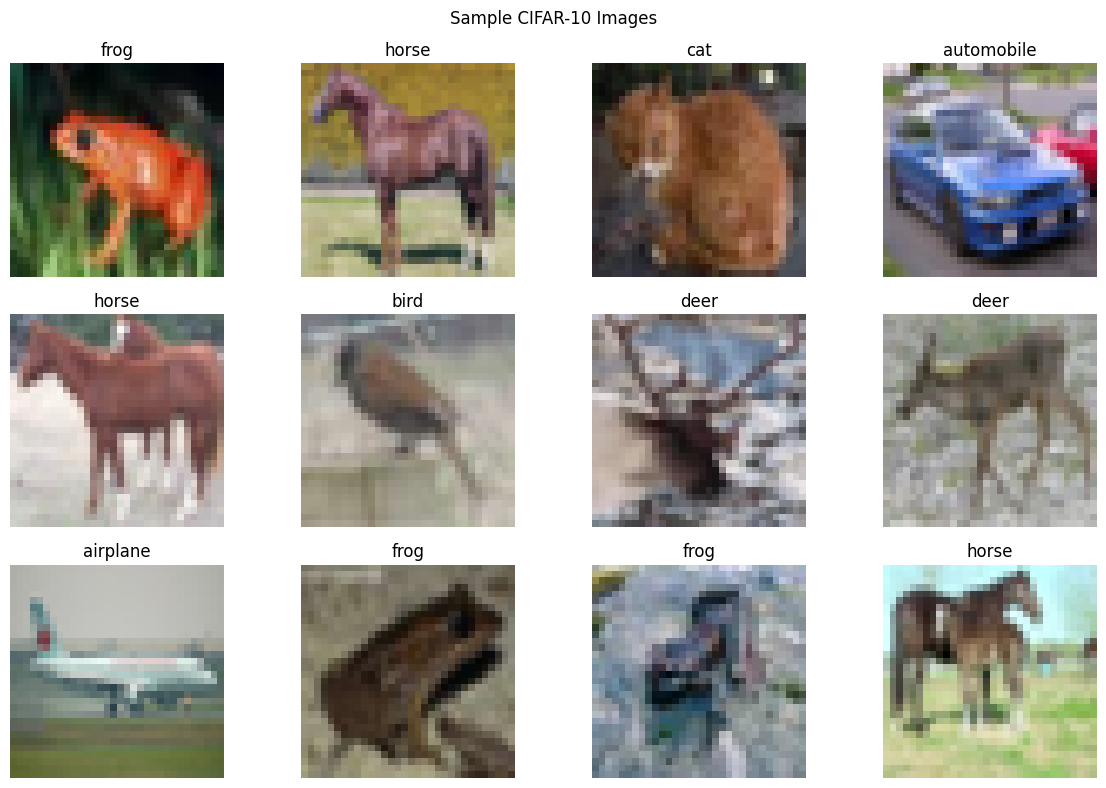

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Processed batch shape: torch.Size([32, 3, 224, 224])
Label batch shape    : torch.Size([32])
Expected image size  : 224 x 224 x 3

TASK A COMPLETED SUCCESSFULLY


In [1]:
# ============================================================
# TASK A: DATASET PREPARATION
# ============================================================

!pip -q install torch torchvision transformers pillow matplotlib

import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, random_split

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

# CIFAR-10 classes
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Transform for ResNet-50: resize to 224x224 and normalize using ImageNet statistics
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Download CIFAR-10
full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Split 50,000 training images into 45,000 train and 5,000 validation
train_size = 45000
val_size = 5000

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print("\n================ DATASET INFORMATION ================")
print("Training images   :", len(train_dataset))
print("Validation images :", len(val_dataset))
print("Testing images    :", len(test_dataset))
print("Number of classes :", len(class_names))
print("Classes           :", class_names)

# Display original CIFAR-10 images using a separate non-normalized dataset
display_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transforms.ToTensor()
)

images, labels = next(iter(DataLoader(display_dataset, batch_size=12, shuffle=True)))

plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

# Check processed batch
sample_images, sample_labels = next(iter(train_loader))

print("\nProcessed batch shape:", sample_images.shape)
print("Label batch shape    :", sample_labels.shape)
print("Expected image size  : 224 x 224 x 3")

print("\nTASK A COMPLETED SUCCESSFULLY")


# TASK B — IMPLEMENTING TRANSFER LEARNING

A ResNet-50 model pre-trained on ImageNet is loaded. Its feature extraction layers are frozen and a new classification layer is added for the 10 CIFAR-10 classes.

In [2]:
# ============================================================
# TASK B: IMPLEMENTING TRANSFER LEARNING USING RESNET-50
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet50, ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Load ImageNet pre-trained ResNet-50
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

# Freeze all pre-trained feature extraction layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final classification layer for CIFAR-10
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.0001
)

print("\n================ MODEL INFORMATION ================")
print("Model             : ResNet-50")
print("Pre-trained on    : ImageNet")
print("Feature layers    : Frozen")
print("Original output   : 1000 ImageNet classes")
print("New output        : 10 CIFAR-10 classes")
print("Optimizer         : Adam")
print("Learning rate     : 0.0001")

print("\nFinal classification layer:")
print(model.fc)

print("\nTrainable parameters:")
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print("Trainable:", f"{trainable:,}")
print("Total    :", f"{total:,}")

print("\nTASK B COMPLETED SUCCESSFULLY")


Device: cpu
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 126MB/s]



================ MODEL INFORMATION ================
Model             : ResNet-50
Pre-trained on    : ImageNet
Feature layers    : Frozen
Original output   : 1000 ImageNet classes
New output        : 10 CIFAR-10 classes
Optimizer         : Adam
Learning rate     : 0.0001

Final classification layer:
Linear(in_features=2048, out_features=10, bias=True)

Trainable parameters:
Trainable: 20,490
Total    : 23,528,522

TASK B COMPLETED SUCCESSFULLY


# TASK C — MODEL TRAINING AND PERFORMANCE EVALUATION

The transfer learning model is trained for a small number of epochs. Training accuracy, validation accuracy, training loss, validation loss, and test accuracy are recorded. Accuracy and loss graphs are also generated.

In [3]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU NOT AVAILABLE")

CUDA available: True
GPU: Tesla T4


TASK C: RESNET-50 TRAINING AND PERFORMANCE EVALUATION
Device: cuda
GPU: Tesla T4

Loading CIFAR-10 dataset...


100%|██████████| 170M/170M [32:59<00:00, 86.2kB/s]



Dataset Information
--------------------------------------------------
Training images   : 5000
Validation images : 1000
Testing images    : 1000
Number of classes : 10

Loading pre-trained ResNet-50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 70.0MB/s]


ResNet-50 loaded successfully.
Pre-trained weights : ImageNet
Frozen layers       : Yes
Output classes       : 10

STARTING 5-EPOCH TRAINING

Epoch [1/5]
Training Loss      : 2.1776
Training Accuracy  : 29.62%
Validation Loss    : 2.0416
Validation Accuracy: 47.40%
Epoch Time         : 19.41 seconds

Epoch [2/5]
Training Loss      : 1.9259
Training Accuracy  : 55.00%
Validation Loss    : 1.8398
Validation Accuracy: 58.50%
Epoch Time         : 17.77 seconds

Epoch [3/5]
Training Loss      : 1.7337
Training Accuracy  : 63.22%
Validation Loss    : 1.6711
Validation Accuracy: 62.40%
Epoch Time         : 18.13 seconds

Epoch [4/5]
Training Loss      : 1.5833
Training Accuracy  : 66.80%
Validation Loss    : 1.5264
Validation Accuracy: 64.50%
Epoch Time         : 18.72 seconds

Epoch [5/5]
Training Loss      : 1.4586
Training Accuracy  : 68.90%
Validation Loss    : 1.4451
Validation Accuracy: 65.30%
Epoch Time         : 18.64 seconds

Total Training Time: 1.54 minutes

TESTING RESNET-50

FINA

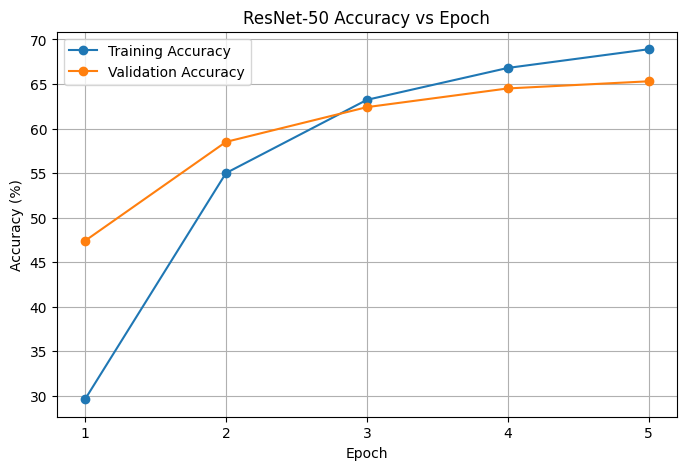

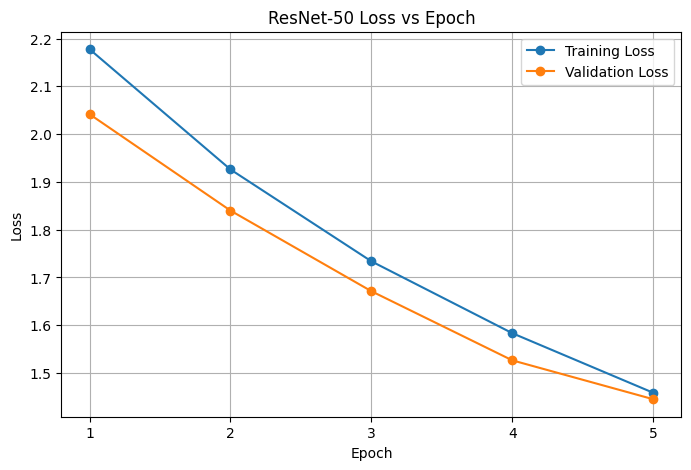


Generating sample predictions...


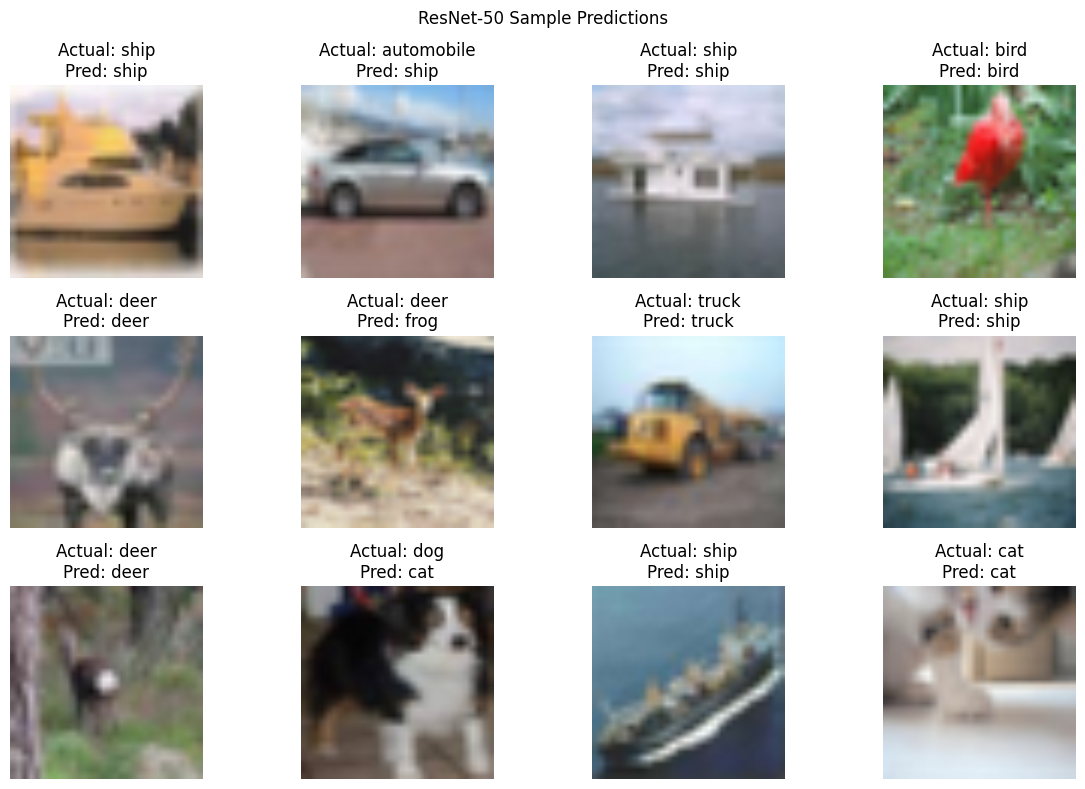


TASK C COMPLETED SUCCESSFULLY

Required results recorded:
✓ Training Accuracy
✓ Validation Accuracy
✓ Training Loss
✓ Validation Loss
✓ Test Accuracy
✓ Accuracy vs Epoch graph
✓ Loss vs Epoch graph
✓ Sample predictions


In [1]:
# ============================================================
# TASK C: TRAINING AND PERFORMANCE EVALUATION
# RESNET-50 TRANSFER LEARNING - 5 EPOCHS
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

from torch.utils.data import DataLoader, random_split
from torchvision.models import resnet50, ResNet50_Weights

# ============================================================
# 1. CHECK GPU
# ============================================================

print("=" * 70)
print("TASK C: RESNET-50 TRAINING AND PERFORMANCE EVALUATION")
print("=" * 70)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU NOT AVAILABLE")

# ============================================================
# 2. DATASET PREPARATION
# ============================================================

print("\nLoading CIFAR-10 dataset...")

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Download training dataset
full_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Download test dataset
test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# ============================================================
# 3. CREATE TRAINING AND VALIDATION SET
# ============================================================

# Use 5000 training images for faster GPU training
TRAIN_SIZE = 5000
VAL_SIZE = 1000

# Take first 6000 images and split them
subset_dataset, _ = random_split(
    full_dataset,
    [TRAIN_SIZE + VAL_SIZE,
     len(full_dataset) - TRAIN_SIZE - VAL_SIZE],
    generator=torch.Generator().manual_seed(42)
)

train_dataset, val_dataset = random_split(
    subset_dataset,
    [TRAIN_SIZE, VAL_SIZE],
    generator=torch.Generator().manual_seed(42)
)

# Use 1000 test images for faster evaluation
test_dataset, _ = random_split(
    test_dataset,
    [1000, 9000],
    generator=torch.Generator().manual_seed(42)
)

# ============================================================
# 4. DATA LOADERS
# ============================================================

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nDataset Information")
print("-" * 50)

print("Training images   :", len(train_dataset))
print("Validation images :", len(val_dataset))
print("Testing images    :", len(test_dataset))
print("Number of classes :", len(class_names))

# ============================================================
# 5. LOAD PRE-TRAINED RESNET-50
# ============================================================

print("\nLoading pre-trained ResNet-50...")

weights = ResNet50_Weights.DEFAULT

model = resnet50(
    weights=weights
)

# ============================================================
# 6. FREEZE FEATURE EXTRACTION LAYERS
# ============================================================

for param in model.parameters():
    param.requires_grad = False

# ============================================================
# 7. REPLACE FINAL CLASSIFICATION LAYER
# ============================================================

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    10
)

model = model.to(device)

print("ResNet-50 loaded successfully.")
print("Pre-trained weights : ImageNet")
print("Frozen layers       : Yes")
print("Output classes       : 10")

# ============================================================
# 8. LOSS AND OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.0001
)

# ============================================================
# 9. TRAINING FUNCTION
# ============================================================

def train_one_epoch():

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


# ============================================================
# 10. VALIDATION FUNCTION
# ============================================================

def validate():

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() *
                images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


# ============================================================
# 11. TRAIN FOR EXACTLY 5 EPOCHS
# ============================================================

EPOCHS = 5

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

print("\n" + "=" * 70)
print("STARTING 5-EPOCH TRAINING")
print("=" * 70)

start_time = time.time()

for epoch in range(EPOCHS):

    epoch_start = time.time()

    train_loss, train_accuracy = train_one_epoch()

    val_loss, val_accuracy = validate()

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    epoch_time = time.time() - epoch_start

    print(
        f"\nEpoch [{epoch + 1}/{EPOCHS}]"
    )

    print(
        f"Training Loss      : "
        f"{train_loss:.4f}"
    )

    print(
        f"Training Accuracy  : "
        f"{train_accuracy * 100:.2f}%"
    )

    print(
        f"Validation Loss    : "
        f"{val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: "
        f"{val_accuracy * 100:.2f}%"
    )

    print(
        f"Epoch Time         : "
        f"{epoch_time:.2f} seconds"
    )

total_time = time.time() - start_time

print(
    "\nTotal Training Time: "
    f"{total_time / 60:.2f} minutes"
)

# ============================================================
# 12. TESTING
# ============================================================

print("\n" + "=" * 70)
print("TESTING RESNET-50")
print("=" * 70)

model.eval()

test_loss_total = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        test_loss_total += (
            loss.item() *
            images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        test_correct += (
            predictions == labels
        ).sum().item()

        test_total += labels.size(0)

test_loss = (
    test_loss_total /
    test_total
)

test_accuracy = (
    test_correct /
    test_total
)

# ============================================================
# 13. FINAL PERFORMANCE
# ============================================================

print("\n" + "=" * 70)
print("FINAL PERFORMANCE RESULTS")
print("=" * 70)

print(
    f"Training Accuracy   : "
    f"{history['train_accuracy'][-1] * 100:.2f}%"
)

print(
    f"Validation Accuracy : "
    f"{history['val_accuracy'][-1] * 100:.2f}%"
)

print(
    f"Training Loss       : "
    f"{history['train_loss'][-1]:.4f}"
)

print(
    f"Validation Loss     : "
    f"{history['val_loss'][-1]:.4f}"
)

print(
    f"Test Accuracy       : "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Test Loss           : "
    f"{test_loss:.4f}"
)

# ============================================================
# 14. ACCURACY VS EPOCH
# ============================================================

epochs = range(
    1,
    EPOCHS + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    [x * 100 for x in history["train_accuracy"]],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    [x * 100 for x in history["val_accuracy"]],
    marker="o",
    label="Validation Accuracy"
)

plt.title(
    "ResNet-50 Accuracy vs Epoch"
)

plt.xlabel("Epoch")

plt.ylabel(
    "Accuracy (%)"
)

plt.xticks(
    range(1, 6)
)

plt.legend()

plt.grid()

plt.show()

# ============================================================
# 15. LOSS VS EPOCH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title(
    "ResNet-50 Loss vs Epoch"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.xticks(
    range(1, 6)
)

plt.legend()

plt.grid()

plt.show()

# ============================================================
# 16. SAMPLE PREDICTIONS
# ============================================================

print("\nGenerating sample predictions...")

images, labels = next(
    iter(test_loader)
)

model.eval()

with torch.no_grad():

    outputs = model(
        images.to(device)
    )

    predictions = outputs.argmax(
        dim=1
    ).cpu()

# Denormalize images
mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)

display_images = (
    images * std + mean
)

display_images = torch.clamp(
    display_images,
    0,
    1
)

plt.figure(figsize=(12, 8))

for i in range(
    min(12, len(images))
):

    plt.subplot(
        3,
        4,
        i + 1
    )

    plt.imshow(
        display_images[i].permute(
            1,
            2,
            0
        )
    )

    plt.title(
        f"Actual: "
        f"{class_names[labels[i]]}\n"
        f"Pred: "
        f"{class_names[predictions[i]]}"
    )

    plt.axis("off")

plt.suptitle(
    "ResNet-50 Sample Predictions"
)

plt.tight_layout()

plt.show()

# ============================================================
# COMPLETION
# ============================================================

print("\n" + "=" * 70)
print("TASK C COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nRequired results recorded:")
print("✓ Training Accuracy")
print("✓ Validation Accuracy")
print("✓ Training Loss")
print("✓ Validation Loss")
print("✓ Test Accuracy")
print("✓ Accuracy vs Epoch graph")
print("✓ Loss vs Epoch graph")
print("✓ Sample predictions")

## OPTIONAL FINE-TUNING

After initial transfer learning, selected deeper ResNet-50 layers can be unfrozen and trained with a very small learning rate. This allows the pre-trained features to adapt to the target dataset.

In [2]:
# OPTIONAL FINE-TUNING
# Run this only if required by your faculty.

# Unfreeze the last part of ResNet-50
for param in model.layer4.parameters():
    param.requires_grad = True

# Keep the earlier layers frozen
for param in model.layer1.parameters():
    param.requires_grad = False
for param in model.layer2.parameters():
    param.requires_grad = False
for param in model.layer3.parameters():
    param.requires_grad = False

# Very small learning rate for fine-tuning
fine_tune_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

print("Fine-tuning configuration completed.")
print("Last ResNet-50 block and classification layer are trainable.")


Fine-tuning configuration completed.
Last ResNet-50 block and classification layer are trainable.


# TASK D — USING HUGGING FACE PRE-TRAINED MODELS

A pre-trained Vision Transformer (ViT) from Hugging Face is loaded and used for image classification. Its prediction is compared with the ResNet-50 prediction.

**Important:** ViT was trained on ImageNet labels, while ResNet-50 above was adapted specifically to the 10 CIFAR-10 classes. Therefore, their labels may not match exactly.

Loading Hugging Face model: google/vit-base-patch16-224


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


Hugging Face model loaded successfully!
Model: google/vit-base-patch16-224
Number of labels: 1000

MODEL COMPARISON
Actual CIFAR-10 class : airplane
ResNet-50 prediction  : frog
Hugging Face ViT label: albatross, mollymawk


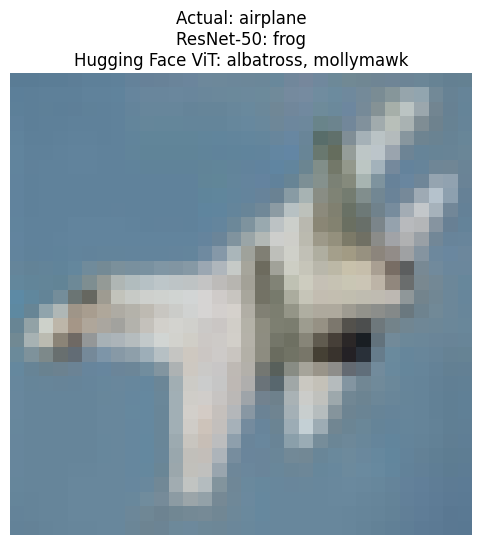


OBSERVATION:
ResNet-50 was trained/fine-tuned for CIFAR-10's 10 classes.
The Hugging Face ViT is an ImageNet model and therefore uses ImageNet labels.
Different predictions are possible because the models use different label spaces.

TASK D COMPLETED SUCCESSFULLY


In [6]:
# ============================================================
# TASK D: HUGGING FACE PRE-TRAINED VISION MODEL
# ============================================================

from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image

HF_MODEL_NAME = "google/vit-base-patch16-224"

print("Loading Hugging Face model:", HF_MODEL_NAME)

processor = AutoImageProcessor.from_pretrained(HF_MODEL_NAME)
hf_model = AutoModelForImageClassification.from_pretrained(HF_MODEL_NAME)

hf_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hf_model = hf_model.to(hf_device)
hf_model.eval()

print("\nHugging Face model loaded successfully!")
print("Model:", HF_MODEL_NAME)
print("Number of labels:", hf_model.config.num_labels)

# Use an original CIFAR-10 test image
sample_index = 10

raw_test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=None
)

raw_image, actual_label_id = raw_test_dataset[sample_index]
actual_label = class_names[actual_label_id]

# Hugging Face prediction
hf_inputs = processor(images=raw_image, return_tensors="pt")
hf_inputs = {k: v.to(hf_device) for k, v in hf_inputs.items()}

with torch.no_grad():
    hf_outputs = hf_model(**hf_inputs)

hf_class_id = hf_outputs.logits.argmax(-1).item()
hf_label = hf_model.config.id2label[hf_class_id]

# ResNet-50 prediction
resnet_input = transform(raw_image).unsqueeze(0).to(device)

with torch.no_grad():
    resnet_output = model(resnet_input)
    resnet_class_id = resnet_output.argmax(1).item()

resnet_label = class_names[resnet_class_id]

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)
print("Actual CIFAR-10 class :", actual_label)
print("ResNet-50 prediction  :", resnet_label)
print("Hugging Face ViT label:", hf_label)

plt.figure(figsize=(6, 6))
plt.imshow(raw_image)
plt.axis("off")
plt.title(
    f"Actual: {actual_label}\n"
    f"ResNet-50: {resnet_label}\n"
    f"Hugging Face ViT: {hf_label}"
)
plt.show()

print("\nOBSERVATION:")
print("ResNet-50 was trained/fine-tuned for CIFAR-10's 10 classes.")
print("The Hugging Face ViT is an ImageNet model and therefore uses ImageNet labels.")
print("Different predictions are possible because the models use different label spaces.")

print("\nTASK D COMPLETED SUCCESSFULLY")


# RESULT

The transfer learning approach using a pre-trained ResNet-50 model was successfully implemented for CIFAR-10 image classification. The ImageNet pre-trained feature extraction layers were frozen and a new classification layer was added for the 10 target classes. The model was trained and evaluated using training, validation, and test datasets. Accuracy and loss graphs were generated. A pre-trained Vision Transformer from Hugging Face was also loaded and used for image classification, and its prediction was compared with the ResNet-50 model.

**Note:** Enter the actual accuracy values produced by your Colab run in the lab record.
